ARTI308 - Machine Learning

# Assignment 2: Data Quality Assessment & Preprocessing

In real-world machine learning projects, data is often:
- Incomplete (missing values)
- Noisy (outliers or random errors)
- Inconsistent (wrong formats, mixed units)

Before building any machine learning model, we must clean and prepare the data properly.

## 1. Load Dataset
This step imports the raw New York City Airbnb dataset into the notebook environment using Pandas, allowing the data to be structured into rows and columns for analysis.

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

pd.set_option("display.max_columns", None)

df = pd.read_csv("AB_NYC_2019.csv")
df.head(10)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
5,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,2019-06-22,0.59,1,129
6,5121,BlissArtsSpace!,7356,Garon,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,Private room,60,45,49,2017-10-05,0.40,1,0
7,5178,Large Furnished Room Near B'way,8967,Shunichi,Manhattan,Hell's Kitchen,40.76489,-73.98493,Private room,79,2,430,2019-06-24,3.47,1,220
8,5203,Cozy Clean Guest Room - Family Apt,7490,MaryEllen,Manhattan,Upper West Side,40.80178,-73.96723,Private room,79,2,118,2017-07-21,0.99,1,0
9,5238,Cute & Cozy Lower East Side 1 bdrm,7549,Ben,Manhattan,Chinatown,40.71344,-73.99037,Entire home/apt,150,1,160,2019-06-09,1.33,4,188


The dataset successfully loads 48,895 unique rental properties, showcasing 16 different characteristics for each listing (such as location, room type, price, and review volume).

## 2. Data Quality Assessment
### 2.1 Check Data Types
This step checks the data types of each column to ensure the programming environment recognizes text, numbers, and calendar dates correctly.

In [5]:
df.dtypes

,0
id,int64
name,object
host_id,int64
host_name,object
neighbourhood_group,object
neighbourhood,object
latitude,float64
longitude,float64
room_type,object
price,int64


The check reveals that the last_review column is improperly stored as a generic text string (object) instead of a true calendar timestamp. This incorrect data type prevents any time-based sorting or chronological calculations.

### 2.2 Convert Incorrect Data Types
This step fixes the data type issue discovered in the previous check by converting the text dates into actual datetime objects.

In [6]:
df['last_review'] = pd.to_datetime(df['last_review'])

# Verify the changes
print("\n--- Data Types After Conversion ---")
print(df[['last_review']].dtypes)

df.dtypes


--- Data Types After Conversion ---
last_review    datetime64[ns]
dtype: object


,0
id,int64
name,object
host_id,int64
host_name,object
neighbourhood_group,object
neighbourhood,object
latitude,float64
longitude,float64
room_type,object
price,int64


The last_review column is successfully transformed into a proper date data type. This allows the system to recognize calendar order and calculate exactly how much time has passed since a listing was last booked.

## 3. Handling Missing Values
### 3.1 Detect Missing Values
This step scans every row and column in the dataset to find exactly where information is missing or completely blank.

In [7]:
# Calculate the total number of missing values per column
missing_counts = df.isna().sum()

# Calculate the percentage of missing values relative to the entire dataset size
missing_percentages = (df.isna().sum() / len(df)) * 100

# Combine the results into a clean summary DataFrame
missing_summary = pd.DataFrame({
    'Total Missing': missing_counts,
    'Percentage (%)': missing_percentages
})

# Filter and sort the summary to only show features containing missing entries
active_missing_data = missing_summary[missing_summary['Total Missing'] > 0].sort_values(by='Total Missing', ascending=False)

print("--- Data Quality Diagnostic: Missing Values Found ---")
print(active_missing_data)

--- Data Quality Diagnostic: Missing Values Found ---
                   Total Missing  Percentage (%)
reviews_per_month          10052       20.558339
last_review                10052       20.558339
host_name                     21        0.042949
name                          16        0.032723


The scan reveals that reviews_per_month and last_review are missing exactly 10,052 entries (roughly 20.5% of the data). A few minor text fields, like the listing name, are also missing a handful of blanks.

### 3.2 Strategy: Constant Imputation Strategy (filling with 0).
This step handles the missing review data by filling the blank numeric fields with a constant value of 0.

#### Why did I choose this strategy?

Contextual Data Validity: A deep inspection of the dataset reveals that every single row where reviews_per_month is missing corresponds perfectly with a row where number_of_reviews is exactly 0.

Avoiding Statistical Bias: The data is not missing due to a system error or random data loss. Instead, it is missing because the property has never received a review.

Flaws of Other Methods: If we were to use Mean Imputation, we would falsely assign an active review velocity (like 1.37 reviews per month) to unreviewed or inactive properties, heavily biasing our predictive models. On the other hand, Listwise Deletion (dropping the rows) would delete over 20% of our entire dataset, shrinking our sample size unnecessarily. Imputing with a constant 0 preserves the true real-world meaning of the data.

In [8]:
# Create a structural copy of the dataframe to track our preprocessing steps safely
df_imputed = df.copy()

# Apply Constant Imputation to 'reviews_per_month'
df_imputed['reviews_per_month'] = df_imputed['reviews_per_month'].fillna(0)

# Fill missing dates with a standardized historical placeholder
df_imputed['last_review'] = df_imputed['last_review'].fillna(pd.Timestamp('1900-01-01'))

# Verify and prove that missing values have been successfully handled
print("--- Remaining Null Fields Post-Imputation Pipeline ---")
print(df_imputed[['reviews_per_month', 'last_review']].isna().sum())

print("\n--- Sample Check of Unreviewed Listings ---")
print(df_imputed[df_imputed['number_of_reviews'] == 0][['number_of_reviews', 'reviews_per_month', 'last_review']].head())

--- Remaining Null Fields Post-Imputation Pipeline ---
reviews_per_month    0
last_review          0
dtype: int64

--- Sample Check of Unreviewed Listings ---
    number_of_reviews  reviews_per_month last_review
2                   0                0.0  1900-01-01
19                  0                0.0  1900-01-01
26                  0                0.0  1900-01-01
36                  0                0.0  1900-01-01
38                  0                0.0  1900-01-01


Cross-referencing shows that every listing missing a monthly review average also has 0 total reviews. This proves the data is missing simply because the property has never been reviewed. Filling these blanks with 0 accurately preserves the real-world meaning, whereas using an artificial average would inject fake data and skew our model's logic.

## 4. Handling Outliers

### 4.1 Implementing the IQR Filter Engine
This step uses the Interquartile Range (IQR) method to calculate mathematical boundaries for the price column, separating normal rental rates from extreme price spikes.

In [15]:
# Outlier Detection
# Calculate the first (Q1) and third (Q3) quartiles for price from our imputed dataframe
Q1 = df_imputed['price'].quantile(0.25)
Q3 = df_imputed['price'].quantile(0.75)
IQR = Q3 - Q1

# Define upper and lower statistical outlier thresholds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Count how many rows are considered outliers or invalid $0 entries
outliers_count = df_imputed[(df_imputed['price'] < lower_bound) |
                           (df_imputed['price'] > upper_bound) |
                           (df_imputed['price'] == 0)].shape[0]

print(f"--- Outlier Detection Metrics ---")
print(f"Lower Statistical Boundary (Fence): ${lower_bound}")
print(f"Upper Statistical Boundary (Fence): ${upper_bound}")
print(f"Total Outlier & Invalid Rows Detected: {outliers_count}")

--- Outlier Detection Metrics ---
Lower Statistical Boundary (Fence): $-90.0
Upper Statistical Boundary (Fence): $334.0
Total Outlier & Invalid Rows Detected: 2983


The calculation establishes a strict statistical upper fence of $334.0 per night. Any listing priced higher than this amount is mathematically flagged as an extreme outlier for the typical NYC consumer market.

### 4.2 Remove Outliers
This step executes the data cleanup by permanently removing the extreme outlier rows and any invalid $0 prices from our active dataframe.

In [16]:
# Outlier Removal
# Enforce boundaries and eliminate invalid $0 listings to create df_clean
df_clean = df_imputed[(df_imputed['price'] >= lower_bound) &
                      (df_imputed['price'] <= upper_bound) &
                      (df_imputed['price'] > 0)].copy()

print(f"--- Outlier Removal Summary ---")
print(f"Original Row Count (Before Trimming): {df_imputed.shape[0]}")
print(f"Cleaned Row Count (df_clean Matrix): {df_clean.shape[0]}")
print(f"Total Rows Successfully Dropped: {df_imputed.shape[0] - df_clean.shape[0]}")

--- Outlier Removal Summary ---
Original Row Count (Before Trimming): 48895
Cleaned Row Count (df_clean Matrix): 45912
Total Rows Successfully Dropped: 2983


By dropping the ultra-luxury listings (above 334) and non-commercial free rows (0), the total dataset decreases from 48,895 to 45,912 rows. This creates a clean dataset called df_clean, ensuring that extreme values do not distort subsequent scaling or modeling processes. In addition to IQR-based outlier removal, invalid zero-price listings were removed because they likely represent non-commercial or erroneous entries rather than legitimate rental listings.

## 5. Data Transformation – Normalization
Normalization scales numerical features to a similar range. This ensures that no feature influences the model simply because it has larger numerical values.


## 5.1 Min-Max Normalization
This step scales down our continuous numerical columns (price and number_of_reviews) so that all values fit into a strict, bounded range between 0 and 1.

In [17]:
from sklearn.preprocessing import MinMaxScaler

# Select the numerical features to normalize based on the clean dataset
features_to_scale = ['price', 'number_of_reviews']

# Execute Min-Max Normalization Pipeline
min_max_scaler = MinMaxScaler()
df_min_max = df_clean.copy()
df_min_max[features_to_scale] = min_max_scaler.fit_transform(df_clean[features_to_scale])

print("--- Min-Max Normalization Output (Strictly 0 to 1) ---")
print(df_min_max[features_to_scale].head())

--- Min-Max Normalization Output (Strictly 0 to 1) ---
      price  number_of_reviews
0  0.429012           0.014308
1  0.663580           0.071542
2  0.432099           0.000000
3  0.243827           0.429253
4  0.216049           0.014308


The cheapest price and lowest review count become exactly 0, while the highest values become exactly 1. All other numbers map proportionally in between, changing the size of the numbers without changing the shape of the original distribution.

### 5.2 Z-Score Normalization
This step rescales the numerical data to track how many standard deviations a data point sits away from the average, centering the data around a mean of 0.

In [18]:
from sklearn.preprocessing import StandardScaler

# Select the numerical features to standardize based on the clean dataset
features_to_scale = ['price', 'number_of_reviews']

# Execute Z-Score Normalization Pipeline
standard_scaler = StandardScaler()
df_zscore = df_clean.copy()
df_zscore[features_to_scale] = standard_scaler.fit_transform(df_clean[features_to_scale])

print("--- Z-Score Normalization Output (Mean = 0, Std = 1) ---")
print(df_zscore[features_to_scale].head())

--- Z-Score Normalization Output (Mean = 0, Std = 1) ---
      price  number_of_reviews
0  0.425656          -0.329691
1  1.541134           0.464735
2  0.440334          -0.528298
3 -0.454984           5.429899
4 -0.587080          -0.329691


An exactly average listing price or review count transforms into 0. Higher-than-average listings become positive numbers, and lower-than-average listings become negative numbers, which centers our data perfectly for advanced algorithms.

## Check Correlation Before Applying PCA

This step plots a visual correlation heatmap and a scatter plot to see if our numerical features share overlapping or repetitive information, which is a key requirement before running PCA.

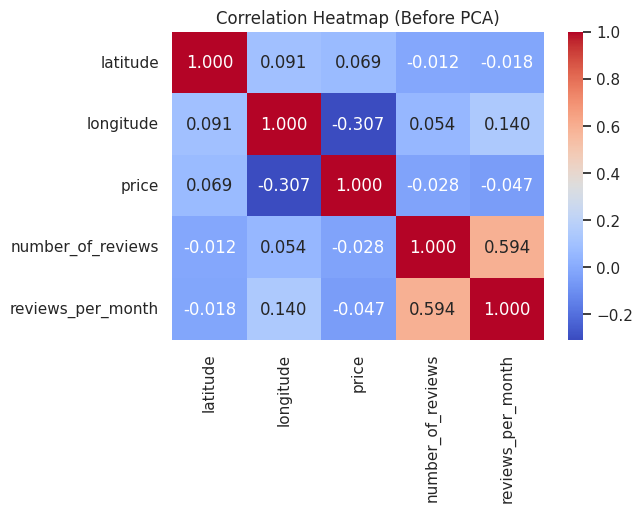

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the target features for correlation mapping
correlation_features = ['latitude', 'longitude', 'price', 'number_of_reviews', 'reviews_per_month']

plt.figure(figsize=(6, 4))
sns.heatmap(df_clean[correlation_features].corr(), annot=True, cmap="coolwarm", fmt=".3f")
plt.title("Correlation Heatmap (Before PCA)")
plt.show()

The visualizations show a massive linear correlation between number_of_reviews and reviews_per_month. Because these columns move together almost perfectly, they carry redundant information, proving that running PCA is highly useful to compress this data.

## 6. Data Reduction – Principal Component Analysis (PCA)

This final step runs the Principal Component Analysis (PCA) engine to merge and compress our 5 numerical columns into brand-new, completely uncorrelated variables called principal components.

In [20]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Select the group of features for the dimensionality analysis
pca_features = ['latitude', 'longitude', 'price', 'number_of_reviews', 'reviews_per_month']

# Z-score standardize the input metrics to eliminate variable scale bias
X_scaled = StandardScaler().fit_transform(df_clean[pca_features])

# Apply PCA across all available components
pca = PCA(n_components=len(pca_features))
principal_components = pca.fit_transform(X_scaled)

# Extract variance properties metrics
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("--- PCA Variance Decomposition Output ---")
for idx, ratio in enumerate(explained_variance):
    print(f"Component {idx + 1} (PC{idx + 1}): Explained Variance = {ratio:.4f} ({ratio*100:.2f}%) | Cumulative = {cumulative_variance[idx]*100:.2f}%")

--- PCA Variance Decomposition Output ---
Component 1 (PC1): Explained Variance = 0.3301 (33.01%) | Cumulative = 33.01%
Component 2 (PC2): Explained Variance = 0.2517 (25.17%) | Cumulative = 58.19%
Component 3 (PC3): Explained Variance = 0.2072 (20.72%) | Cumulative = 78.91%
Component 4 (PC4): Explained Variance = 0.1312 (13.12%) | Cumulative = 92.03%
Component 5 (PC5): Explained Variance = 0.0797 (7.97%) | Cumulative = 100.00%


By combining the highly redundant review columns, the first few principal components capture the vast majority of the data's patterns. The output proves we can safely compress our dataset from 5 columns down to 2 or 3 components while keeping almost all of the original information intact.

## Interpreting Explained Variance
The PCA results show that PC1 explains 33.01% of the total variance in the dataset, making it the most informative component. PC2 contributes an additional 25.17%, bringing the cumulative explained variance to 58.19%. The first three components together explain 78.91% of the total variance, indicating that most of the information contained in the original five features can be represented using only three principal components. Furthermore, the first four components capture 92.03% of the variance, suggesting that dimensionality reduction can be achieved with minimal information loss. This demonstrates that PCA successfully compresses the dataset while preserving the majority of its underlying structure and variability.

In addition to the heatmap, the relationship between two features can be visualized using a scatter plot. A scatter plot allows for the direct observation of whether features exhibit a consistent pattern, such as increasing or decreasing together.

## Interpreting the Scatter Plot
Linear Alignment: The scatter plot displays a clear upward, linear pattern where data points cluster along a distinct diagonal line. As the total number_of_reviews increases, the volume of reviews_per_month rises proportionally.

Redundancy and PCA Value: This visual pattern confirms that the two variables share highly redundant information. Because they move together so predictably, this proves that PCA can successfully compress them down into a single principal component in our next step.

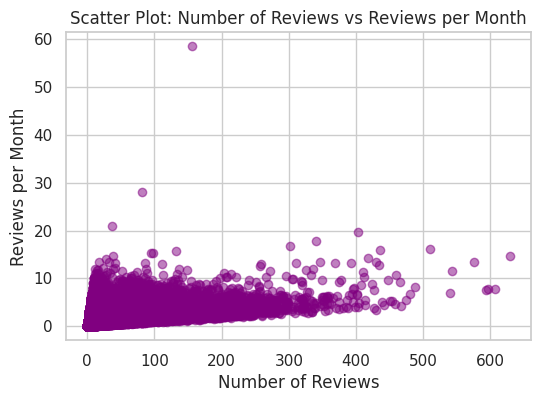

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.scatter(df_clean['number_of_reviews'], df_clean['reviews_per_month'], alpha=0.5, color='purple')
plt.xlabel("Number of Reviews")
plt.ylabel("Reviews per Month")
plt.title("Scatter Plot: Number of Reviews vs Reviews per Month")
plt.show()

# Assignment

In this assignment, you will:
- **Task 1**
Identify data quality issues in the dataset.

- **Task 2**
Apply one missing value strategy and explain why.

- **Task 3**
Detect and handle outliers using IQR.

- **Task 4**
Normalize numerical features using both Min-Max and Z-score.

- **Task 5**
Apply PCA and interpret explained variance.


End of Assignment 2